# Financial evaluation — P&L-optimal approval threshold, all models

The model notebooks classify at a 0.5 cut-off, a statistical convention that ignores what each
decision is worth. This notebook sets each model's approval threshold from the lender's economics and
compares the three models in dollars, on the same test applicants. Nothing is retrained here.

**Inputs:**
- `data/processed/{val,test}.parquet` — each applicant's true outcome and `loan_amount`
- each model's approval probabilities (section 2): logreg and XGBoost are scored live from their saved
  models in `models/`; TabPFN needs a GPU to score 1.37M rows, so its scores come from its own exports
  in `data/tabpfn-results/`, written by `notebooks/tabpfn.ipynb`

**Outputs** (`outputs/evaluation/financial/`): the P&L table, the chosen thresholds and the two charts.

**Method:** each threshold is chosen on **val** and applied unchanged to **test**, so the test P&L is
an honest estimate of what the lender would earn.

In [8]:
import sys
from functools import lru_cache
from pathlib import Path
sys.path.append(str(Path("../..").resolve()))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import common_metrics as cm

NB_OUTPUT_DIR = cm.OUTPUT_DIR / "financial"
NB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cm.report_status()

Ready:   ['xgboost', 'logreg', 'tabpfn']
Waiting: (none — all models in)


## 1. Framing and cost matrix

**Framing.** The target is the lender's *decision*, not loan default (HMDA has no repayment data).
So the client is a lender using a model as an automated first-pass underwriter, and each decision
is scored against what full manual underwriting decided. P&L is computed **loan by loan**, in
proportion to each application's `loan_amount`:

| | actually approved (y=1) | actually denied (y=0) |
|---|---|---|
| **model approves** | + `MARGIN` × loan amount — lifetime net margin on a good loan | − `LGD` × loan amount — a loan underwriting would reject gets through and defaults |
| **model denies** | 0 — forgone profit (shows up as the gap to the oracle) | 0 — correct rejection |

- `MARGIN = 3%`: lifetime net margin on a mortgage (typically 1–3% of the loan).
- `LGD = 35%`: loss given default. A mortgage is secured by the house, so on default the lender
  recovers most of the loan through foreclosure; typical losses are 25–40% of the loan.
- Conservative simplification: every approval the lender would have denied is treated as a default.

⚠️ **These two rates must be agreed by the whole team.** `common_metrics.TEAM_THRESHOLD`, used by the
fairness notebook, is derived from them. (`common_metrics.team_pnl_fn` is still a count-based
placeholder and isn't used here.)

**Threshold.** With calibrated probabilities, approving loan *i* pays off when
`p × MARGIN × amount > (1 − p) × LGD × amount`. The loan amount cancels out, so the threshold is the
same for every applicant: `p > LGD / (MARGIN + LGD)` = 0.35 / 0.38 ≈ **0.921**. A bad approval costs
about 12 times what a good one earns, so a model should only approve applicants it's at least 92% sure
of. That formula only holds if a model's probabilities are calibrated, so section 3 also finds each
model's P&L-maximising threshold on val, and that is the threshold we use.

In [9]:
MARGIN = 0.03   # lifetime net margin on a good loan, share of loan_amount — agree with team
LGD = 0.35      # loss given default on a bad approval, share of loan_amount — agree with team

MODEL_CUTOFF = 0.5                              # cut-off used in the model notebooks
THEORETICAL_THRESHOLD = LGD / (MARGIN + LGD)    # ≈ 0.921, valid for calibrated probabilities
GRID = np.linspace(0.50, 0.995, 100)            # thresholds swept on val


def pnl(y, approve, loan_amount):
    """Loan-level P&L in $: +MARGIN × amount per good approval, −LGD × amount per bad approval."""
    y = np.asarray(y)
    approve = np.asarray(approve, dtype=bool)
    amount = np.asarray(loan_amount, dtype=float)
    return MARGIN * amount[approve & (y == 1)].sum() - LGD * amount[approve & (y == 0)].sum()


print(f"theoretical threshold: {THEORETICAL_THRESHOLD:.3f}")

theoretical threshold: 0.921


## 2. Scores for every model

Each model's calibrated approval probability for every val and test applicant, joined to the
applicant's true outcome and `loan_amount` by row position in the split file.

- **Live** (logreg, XGBoost): the saved model in `models/` scores the full val and test splits, so
  both splits come from the same model object. XGBoost takes a few minutes (thousands of trees × 2.7M rows).
- **Export** (TabPFN): its own prediction files. Its val file is the stratified ~20k-row sample its
  notebook scored, so its threshold is chosen on fewer rows than the others' (a noisier choice).

An export is only usable if it was made on the *current* split files: the check below compares its
true outcome and demographics with the split, row by row, and skips the model if they don't line up.
Re-running that model's notebook on the current data fixes it. Each model goes through
`cm.run_step`, so one failing doesn't stop the others.

In [ ]:
SCORE_SOURCE = {"logreg": "live", "xgboost": "live", "tabpfn": "export"}
EXPORT_DIR = {"tabpfn": cm.REPO_ROOT / "data" / "tabpfn-results"}
ALIGN_COLS = ["derived_race", "derived_sex", "applicant_age"]  # compared with the export, when it has them
SPLITS = ("val", "test")

data = {
    split: pd.read_parquet(cm.DATA_DIR / f"{split}.parquet", columns=cm.FEATURES + ["target"] + cm.AUDIT_COLS)
    for split in SPLITS
}
modules = cm.available_models()


@lru_cache
def saved_model(name):
    path = cm.ARTIFACTS_DIR / f"{name}_model.joblib"
    if not path.exists():
        raise FileNotFoundError(f"{path.name} not found — run the {name} training notebook first")
    return joblib.load(path)


def live_scores(name, split):
    rows = np.arange(len(data[split]))
    return rows, modules[name].predict_proba(saved_model(name), data[split])[:, 1]


def export_scores(name, split):
    path = EXPORT_DIR[name] / f"{split}_predictions_with_sensitive.parquet"
    exported = pd.read_parquet(path)
    rows = exported.index.to_numpy()
    current = data[split].iloc[rows]
    match = {"target": np.mean(exported["true_target"].to_numpy() == current["target"].to_numpy())}
    match |= {c: np.mean(exported[c].astype(str).to_numpy() == current[c].astype(str).to_numpy())
              for c in ALIGN_COLS if c in exported.columns}
    if min(match.values()) < 1:
        raise ValueError(
            f"{path.name} doesn't line up with the current {split}.parquet (rows matching: "
            + ", ".join(f"{c} {m:.1%}" for c, m in match.items())
            + f") — it was made on an older split; re-run notebooks/{name}.ipynb")
    return rows, exported["predicted_probability"].to_numpy()


def get_scores(name, split):
    rows, p = (live_scores if SCORE_SOURCE[name] == "live" else export_scores)(name, split)
    current = data[split].iloc[rows]
    return pd.DataFrame({"y": current["target"].to_numpy(), "p": p,
                         "amount": current["loan_amount"].to_numpy()}, index=rows)


scores = {}
for name in modules:
    for split in SPLITS:
        key = f"{name} {split}"
        if cm.run_step(scores, key, get_scores, name, split):
            s = scores[key]
            print(f"{key:13s} {len(s):>9,} rows ({SCORE_SOURCE[name]})  AUC {roc_auc_score(s.y, s.p):.4f}")

ready = [name for name in modules if all(f"{name} {split}" in scores for split in SPLITS)]
print(f"\nmodels in the financial comparison: {ready}")

## 3. Choosing each model's threshold (val)

For every model, P&L on val across thresholds from 0.50 to 0.995; the threshold with the highest P&L
is that model's decision threshold. P&L is shown as a share of the loan volume applied for, so curves
computed on different numbers of rows (TabPFN's val sample) stay comparable. The dashed line is the
theoretical 0.921: a model whose optimum lands far from it has miscalibrated probabilities.

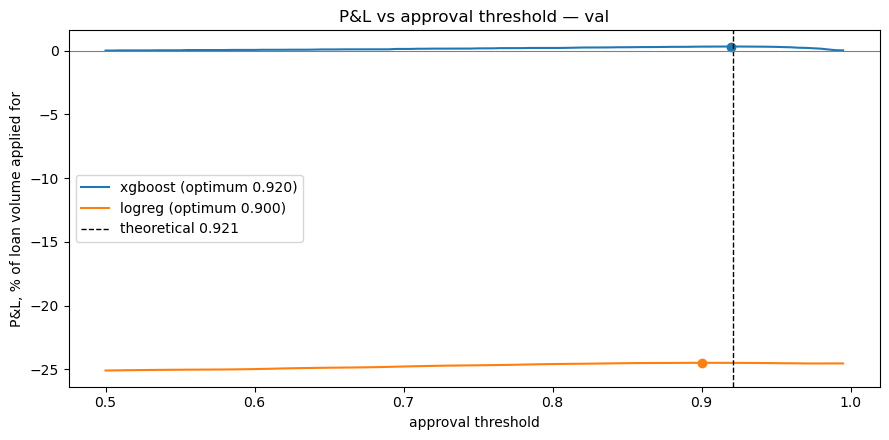

xgboost    0.92
logreg     0.90
Name: val-optimal threshold, dtype: float64

In [ ]:
curves, chosen = {}, {}
for name in ready:
    val_scores = scores[f"{name} val"]
    curves[name] = np.array([pnl(val_scores.y, val_scores.p >= t, val_scores.amount) for t in GRID])
    curves[name] /= val_scores.amount.sum()
    chosen[name] = float(GRID[curves[name].argmax()])

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, curve in curves.items():
    (line,) = ax.plot(GRID, curve * 100, label=f"{name} (optimum {chosen[name]:.3f})")
    ax.plot(chosen[name], curve.max() * 100, "o", color=line.get_color())
ax.axvline(THEORETICAL_THRESHOLD, color="k", ls="--", lw=1, label=f"theoretical {THEORETICAL_THRESHOLD:.3f}")
ax.axhline(0, color="grey", lw=0.8)
ax.set(xlabel="approval threshold", ylabel="P&L, % of loan volume applied for",
       title="P&L vs approval threshold — val")
ax.legend()
plt.tight_layout()
fig.savefig(NB_OUTPUT_DIR / "financial_pnl_vs_threshold_val.png", dpi=150, bbox_inches="tight")
plt.show()

pd.Series(chosen, name="val-optimal threshold").round(3)

## 4. P&L on test

Each model's test P&L at three thresholds: 0.5 (the model notebooks' cut-off), the theoretical 0.921,
and its val-optimal threshold (the one we recommend). Two baselines frame the numbers: approving
everyone (the lender with no model) and the oracle (perfect underwriting, the most any model could
earn). `share of oracle` is the fraction of that maximum a model captures, computed on the model's
own test rows.

In [ ]:
test_y, test_amount = data["test"]["target"].to_numpy(), data["test"]["loan_amount"].to_numpy()
oracle_pnl = pnl(test_y, test_y == 1, test_amount)
everyone_pnl = pnl(test_y, np.ones_like(test_y, dtype=bool), test_amount)

table = [
    {"model": "approve everyone", "threshold rule": "—", "threshold": np.nan, "approval rate": 1.0,
     "P&L ($bn)": everyone_pnl / 1e9, "share of oracle": everyone_pnl / oracle_pnl},
    {"model": "oracle", "threshold rule": "—", "threshold": np.nan, "approval rate": test_y.mean(),
     "P&L ($bn)": oracle_pnl / 1e9, "share of oracle": 1.0},
]
for name in ready:
    test_scores = scores[f"{name} test"]
    model_oracle = pnl(test_scores.y, test_scores.y == 1, test_scores.amount)
    for rule, threshold in [("0.5 cut-off", MODEL_CUTOFF), ("theoretical", THEORETICAL_THRESHOLD),
                            ("val-optimal", chosen[name])]:
        approve = test_scores.p >= threshold
        value = pnl(test_scores.y, approve, test_scores.amount)
        table.append({"model": name, "threshold rule": rule, "threshold": threshold,
                      "approval rate": approve.mean(), "P&L ($bn)": value / 1e9,
                      "share of oracle": value / model_oracle})
    if len(test_scores) != len(test_y):
        print(f"note: {name} was scored on {len(test_scores):,} of {len(test_y):,} test rows — "
              "compare its share of oracle, not its $")

summary = pd.DataFrame(table)
summary.round(3)

,model,threshold rule,threshold,approval rate,P&L ($bn),share of oracle
0,approve everyone,—,NaN,1.000,-12.144,-1.116
1,oracle,—,NaN,0.775,10.879,1.000
2,xgboost,0.5 cut-off,0.500,0.845,0.477,0.044
3,xgboost,theoretical,0.921,0.473,4.700,0.432
4,xgboost,val-optimal,0.920,0.473,4.700,0.432
5,logreg,0.5 cut-off,0.500,0.908,-7.326,-0.673
6,logreg,theoretical,0.921,0.205,1.376,0.127
7,logreg,val-optimal,0.900,0.289,1.407,0.129


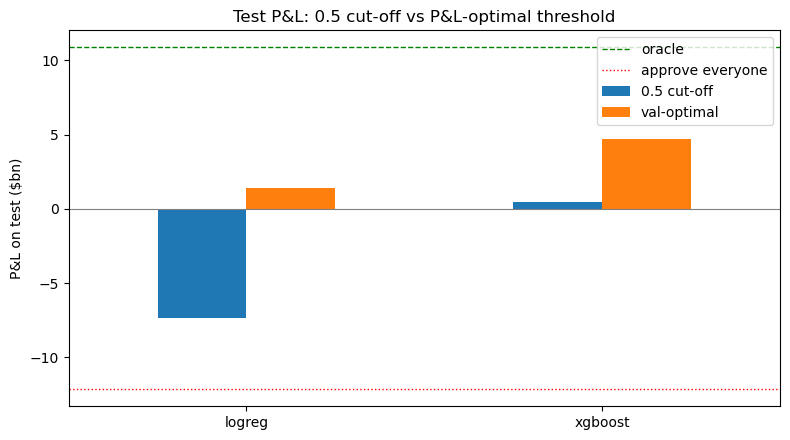

In [ ]:
if ready:
    by_rule = (summary[summary["model"].isin(ready)]
               .pivot(index="model", columns="threshold rule", values="P&L ($bn)")
               [["0.5 cut-off", "val-optimal"]])
    ax = by_rule.plot(kind="bar", figsize=(8, 4.5), rot=0)
    ax.axhline(oracle_pnl / 1e9, color="green", ls="--", lw=1, label="oracle")
    ax.axhline(everyone_pnl / 1e9, color="red", ls=":", lw=1, label="approve everyone")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set(ylabel="P&L on test ($bn)", xlabel="", title="Test P&L: 0.5 cut-off vs P&L-optimal threshold")
    ax.legend()
    plt.tight_layout()
    ax.figure.savefig(NB_OUTPUT_DIR / "financial_pnl_test.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5. Save outputs

`chosen_thresholds.json` holds each model's val-optimal threshold. The fairness notebook currently
applies `common_metrics.TEAM_THRESHOLD` (the theoretical 0.921) to every model; if the team adopts the
per-model thresholds, fairness should read them from here so both notebooks judge the same decisions.

In [ ]:
summary.to_csv(NB_OUTPUT_DIR / "financial_summary.csv", index=False)
(NB_OUTPUT_DIR / "chosen_thresholds.json").write_text(json.dumps(
    {"margin": MARGIN, "lgd": LGD, "theoretical": THEORETICAL_THRESHOLD, "val_optimal": chosen}, indent=2))
print(f"saved to {NB_OUTPUT_DIR}/")

saved to /Users/luccagazotto/Documents/HEC/Interpretability stability and algorithmic fairness/Final project/US_morgage_acceptance/outputs/evaluation/financial/
